# Difference-in-Differences Regression

## 0. Imports and Data Loading

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

In [ ]:
column_dtypes = {
    "code": str,  # Keep FIPS as strings to protect leading zeros
    "treatment": int,
    "year": int,
    "post": int,
    "poverty_indicator": int,
}

df = pd.read_csv(
    "data/clean_hcv_data.csv",
    dtype=column_dtypes,
)
df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0


## 1. Prepare Model

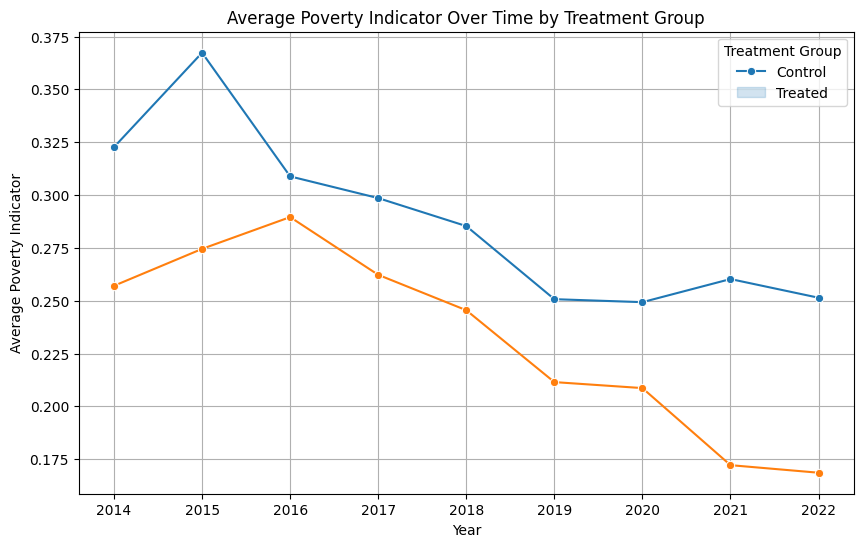

In [ ]:
# Pre-Trend Check
# Plot average poverty_indicator over time for treated vs control groups to visually inspect for parallel trends before treatment implementation.

trends = df.groupby(["year", "treatment"])["poverty_indicator"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=trends, x="year", y="poverty_indicator", hue="treatment", marker="o")
plt.title("Average Poverty Indicator Over Time by Treatment Group")
plt.xlabel("Year")
plt.ylabel("Average Poverty Indicator")
plt.legend(title="Treatment Group", labels=["Control", "Treated"])
plt.grid()
plt.show()

In [ ]:
# Interaction term
df["did_interaction"] = df["treatment"] * df["post"]

# Set multi-index for panel data
reg_df = df.set_index(["code", "year"])

## 2. Define and Run Model

In [ ]:
y = reg_df["number_reported"]
x = reg_df[["did_interaction", "hh_income", "rent_per_month", "tpoverty"]]

model = PanelOLS(y, x, entity_effects=True, time_effects=True)

# Fit with clustered standard errors
results = model.fit(cov_type="clustered", cluster_entity=True)
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        number_reported   R-squared:                        0.0465
Estimator:                   PanelOLS   R-squared (Between):             -0.4276
No. Observations:                5703   R-squared (Within):               0.0611
Date:                Mon, Apr 20 2026   R-squared (Overall):             -0.3848
Time:                        11:41:15   Log-likelihood                -2.465e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      60.012
Entities:                         767   P-value                           0.0000
Avg Obs:                       7.4355   Distribution:                  F(4,4924)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             13.148
                            

Our Difference-in-Differences (DiD) analysis reveals a statstically significant finding. Most critically, the `did_interaction` coefficient has a value of -11.202, which suggests that, in the period following the 2018 mandate, metropolitan tracts in Dallas (the treatment group) saw an average reduction of approximately 11.2 voucher-holding households per tract relative to the control group in Houston. In a DiD framework, this negative coefficient supports the hypothesis that the shift to Small Area Fair Market Rents (SAFMRs) allowed families to move out of the tracts where they were historically clustered. 

When looking at the time-varying controls, the `rent_per_month` coefficient is also highly significant at -0.0630 ($p < 0.000$). This implies that for every $\$100$ increase in the median gross rent of a tract, the number of voucher holders decreases by approximately 6.3 households. 

Within this fixed-effects specification, `tpoverty` and `hh_income` were not statistically significant predictors of the change in voucher counts ($p = 0.549$ and $p = 0.704$, respectively). This lack of significance in the controls is actually a sign of a robust model; because we utilized Entity (Tract) Fixed Effects, the model has already accounted for the baseline socioeconomic status of each neighborhood. Therefore, the regression is isolating the specific impact of the policy change rather than simply reflecting the fact that voucher holders tend to live in lower-income areas. 

From a technical standpoint, the model performance is solid for an academic policy analysis. The Within R-squared value of 0.0611 indicates that our model explains 6.11% of the variation in voucher movement over time within the tracts, which is a meaningful figure given the high degree of inertia in residential housing patterns. The F-test for Poolability (88.32, $p < 0.000$) strongly justifies the inclusion of both Entity and Time effects, confirming that there are significant unobserved differences between tracts and across years that a standard OLS model would have missed. With 5,703 observations across 767 unique entities, the analysis has sufficient power to conclude that the 2018 mandate successfully disrupted the geographic status quo of the HCV program in the treatment area.